# Lab 1: Linear Regression, from Algebra to Bayes

**ECON5129 Statistical Machine Learning** &middot; Adam Smith Business School, University of Glasgow

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/korobilis/ECON5129-labs/blob/main/labs/lab01_regression.ipynb)

This lab accompanies Lecture 1. By the end of the session you should be able to:

1. Compute the least squares estimator three different ways and explain why the textbook formula is the wrong way to program it.
2. Show what a multiple regression coefficient measures, by recovering it from two simple regressions on residuals.
3. Separate in-sample fit from out-of-sample prediction, and demonstrate that the first is no evidence of the second.
4. Verify the sampling properties of $\widehat{\boldsymbol{\beta}}$ by simulation, and see through the singular value decomposition why collinearity inflates variance.
5. Fit nonlinear functions with a linear model through basis expansions, and watch overfitting appear.
6. Estimate the same model by maximum likelihood, and change the likelihood to change the estimator.
7. Derive the Bayesian posterior numerically and produce predictive intervals.

**Plan for the session**

| Time | Part |
|---|---|
| 0:00 - 0:10 | Setup |
| 0:10 - 0:25 | Part 1. Least squares three ways |
| 0:25 - 0:45 | Part 2. What a coefficient measures |
| 0:45 - 1:00 | Part 3. Fit versus prediction |
| 1:00 - 1:15 | Part 4. Sampling properties |
| 1:15 - 1:35 | Part 5. Basis expansions and overfitting |
| 1:35 - 1:45 | Part 6. Maximum likelihood |
| 1:45 - 2:00 | Part 7. Bayesian regression, and Part 8 on real data |

Notation follows the lecture: $n$ observations indexed by $i = 1, \dots, n$, $p$ predictors, design matrix $\mathbf{X}$, coefficient vector $\boldsymbol{\beta}$.

## Setup

**If you are running this on Google Colab, save your own copy now**: `File` &rarr; `Save a copy in Drive`. Otherwise everything you write during the next two hours disappears when you close the tab.

The cell below downloads the course helper module if it is not already present, then imports everything the lab needs. It works identically on Colab and on a local Anaconda installation.

In [4]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/korobilis/ECON5129-labs/main"


if not os.path.exists("econ5129_utils.py"):
    urllib.request.urlretrieve(f"{REPO_RAW}/econ5129_utils.py", "econ5129_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

import econ5129_utils as e5

e5.set_style()
rng = np.random.default_rng(5129)

print(f"numpy {np.__version__}, pandas {pd.__version__}")

numpy 2.1.3, pandas 2.2.3


## Part 1. Least squares three ways

The linear model is

$$ y_i = \mathbf{x}_i' \boldsymbol{\beta} + \varepsilon_i, \qquad i = 1, \dots, n, $$

or in matrix form $\mathbf{y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\varepsilon}$. Least squares minimises the residual sum of squares and solves the normal equations

$$ \mathbf{X}'\mathbf{X} \widehat{\boldsymbol{\beta}} = \mathbf{X}'\mathbf{y}. $$

We start with simulated data, so that we know the answer we are trying to recover.

In [5]:
n, p = 200, 3
beta_true = np.array([1.0, -2.0, 0.5, 3.0])   # intercept first
sigma = 1.0

X_raw = rng.normal(size=(n, p))
X = np.column_stack([np.ones(n), X_raw])       # add the intercept column
y = X @ beta_true + sigma * rng.normal(size=n)

print(f"X has shape {X.shape}, y has shape {y.shape}")

X has shape (200, 4), y has shape (200,)


Three routes to the same estimator.

**Route 1: solve the normal equations.** This forms $\mathbf{X}'\mathbf{X}$ and $\mathbf{X}'\mathbf{y}$ and asks a linear solver for the answer. Note that we never invert anything.

In [6]:
XtX = X.T @ X
Xty = X.T @ y
beta_normal = np.linalg.solve(XtX, Xty)

**Route 2: least squares directly.** `np.linalg.lstsq` works from a QR decomposition of $\mathbf{X}$, so it never forms $\mathbf{X}'\mathbf{X}$ at all. This matters because squaring a matrix squares its condition number.

In [7]:
beta_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)

**Route 3: scikit-learn.** The interface you will use for the rest of the course. `fit_intercept=False` because our design matrix already contains a column of ones.

In [8]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression(fit_intercept=False).fit(X, y)
beta_sklearn = ols.coef_

In [9]:
comparison = pd.DataFrame(
    {
        "true": beta_true,
        "normal equations": beta_normal,
        "lstsq (QR)": beta_lstsq,
        "scikit-learn": beta_sklearn,
    },
    index=["intercept", "x1", "x2", "x3"],
)
comparison.round(6)

,true,normal equations,lstsq (QR),scikit-learn
intercept,1.0,1.118562,1.118562,1.118562
x1,-2.0,-2.102422,-2.102422,-2.102422
x2,0.5,0.505139,0.505139,0.505139
x3,3.0,3.061048,3.061048,3.061048


All three agree to printing precision, and all three are close to but not equal to the truth. That gap is estimation error, and quantifying it is the subject of Part 3.

### Why you should never write `inv(X'X)`

The formula $\widehat{\boldsymbol{\beta}} = (\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'\mathbf{y}$ is how the estimator is *defined*, not how it should be *computed*. Explicit inversion is slower and numerically worse. The following design is nearly collinear, which is exactly the situation where the difference shows up.

In [12]:
z1 = rng.normal(size=n)
z2 = z1 + 1e-7 * rng.normal(size=n)          # almost identical to z1
X_ill = np.column_stack([np.ones(n), z1, z2])
y_ill = X_ill @ np.array([1.0, 2.0, -1.0]) + 0.1 * rng.normal(size=n)

beta_inv = np.linalg.inv(X_ill.T @ X_ill) @ (X_ill.T @ y_ill)
beta_qr, *_ = np.linalg.lstsq(X_ill, y_ill, rcond=None)

print(f"condition number of X      : {np.linalg.cond(X_ill):.3e}")
print(f"condition number of X'X    : {np.linalg.cond(X_ill.T @ X_ill):.3e}")
print(f"residual sum of squares, inv: {np.sum((y_ill - X_ill @ beta_inv) ** 2):.8f}")
print(f"residual sum of squares, QR : {np.sum((y_ill - X_ill @ beta_qr) ** 2):.8f}")

condition number of X      : 1.812e+07
condition number of X'X    : 3.751e+14
residual sum of squares, inv: 1.99033387
residual sum of squares, QR : 1.88858756


The condition number of $\mathbf{X}'\mathbf{X}$ is the square of the condition number of $\mathbf{X}$: forming the cross-product matrix throws away half of your available precision. Use `solve` or `lstsq`, never `inv`.

### Exercise 1

Write a function `ols(X, y)` that returns a dictionary containing the coefficient vector, the residual vector, the unbiased error variance estimate

$$ s^2 = \frac{1}{n - p} \sum_{i=1}^{n} \widehat{\varepsilon}_i^2 $$

(where $p$ counts the intercept), the standard errors $\sqrt{s^2 [(\mathbf{X}'\mathbf{X})^{-1}]_{jj}}$, the $t$ statistics, and $R^2$. Use it on the simulated data and check that the true coefficients lie inside the implied 95% confidence intervals.

In [13]:
def ols(X, y):
    """Least squares estimation with standard errors."""
    # your code here

## Part 2. What a coefficient measures

A multiple regression coefficient is not the relationship between $y$ and $x_j$. It is the relationship between the part of $y$ that the other predictors cannot explain and the part of $x_j$ that the other predictors cannot explain. The Frisch-Waugh-Lovell theorem states this precisely:

$$ \widehat{\beta}_j = \frac{\widetilde{\mathbf{x}}_j' \widetilde{\mathbf{y}}}{\widetilde{\mathbf{x}}_j' \widetilde{\mathbf{x}}_j}, $$

where $\widetilde{\mathbf{y}}$ and $\widetilde{\mathbf{x}}_j$ are the residuals from regressing $\mathbf{y}$ and $\mathbf{x}_j$ respectively on all the *other* predictors.

This is not a curiosity. It is the reason a coefficient can change sign when a control is added, the logic behind every partialling-out argument in applied econometrics, and the device that makes modern high-dimensional causal estimators work.

The predictors need to be correlated for any of it to bite, so we build a design where they are.

In [14]:
n_fwl = 300
Sigma_fwl = np.array([[1.0, 0.8, 0.3], [0.8, 1.0, 0.5], [0.3, 0.5, 1.0]])
X_fwl = np.column_stack([
    np.ones(n_fwl),
    rng.multivariate_normal(np.zeros(3), Sigma_fwl, size=n_fwl),
])
y_fwl = X_fwl @ beta_true + sigma * rng.normal(size=n_fwl)

beta_multiple, *_ = np.linalg.lstsq(X_fwl, y_fwl, rcond=None)

Now recover the coefficient on $x_1$ the long way round: strip out the influence of the other predictors from both sides, then run one simple regression on the leftovers.

In [15]:
others = np.delete(X_fwl, 1, axis=1)          # intercept, x2, x3

y_resid = y_fwl - others @ np.linalg.lstsq(others, y_fwl, rcond=None)[0]
x1_resid = X_fwl[:, 1] - others @ np.linalg.lstsq(others, X_fwl[:, 1], rcond=None)[0]

beta_partialled = (x1_resid @ y_resid) / (x1_resid @ x1_resid)

print(f"coefficient on x1, multiple regression : {beta_multiple[1]:.10f}")
print(f"coefficient on x1, partialled out      : {beta_partialled:.10f}")
print(f"difference                             : {abs(beta_multiple[1] - beta_partialled):.2e}")

coefficient on x1, multiple regression : -1.9887287394
coefficient on x1, partialled out      : -1.9887287394
difference                             : 2.22e-16


The two agree to machine precision. Plotting the residualised variables against each other gives the added-variable plot, which shows the only variation in $x_1$ that the coefficient is actually estimated from.

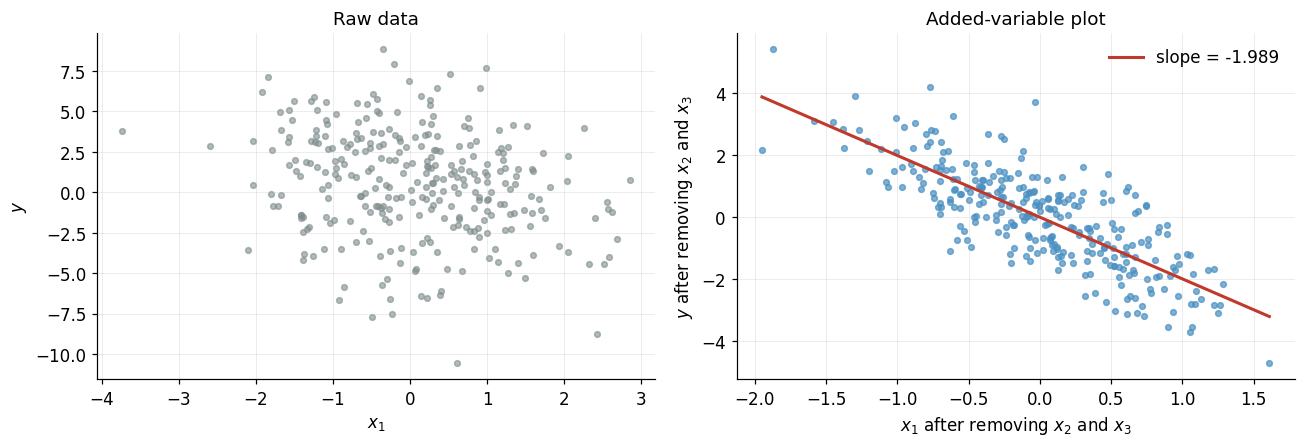

variance of x1              : 1.1923
variance of x1 after partialling: 0.3938


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(X_fwl[:, 1], y_fwl, s=14, color=e5.COLORS[6], alpha=0.6)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$y$")
axes[0].set_title("Raw data")

axes[1].scatter(x1_resid, y_resid, s=14, color=e5.COLORS[1], alpha=0.7)
line = np.linspace(x1_resid.min(), x1_resid.max(), 50)
axes[1].plot(line, beta_partialled * line, color=e5.COLORS[2], lw=2,
             label=f"slope = {beta_partialled:.3f}")
axes[1].set_xlabel("$x_1$ after removing $x_2$ and $x_3$")
axes[1].set_ylabel("$y$ after removing $x_2$ and $x_3$")
axes[1].set_title("Added-variable plot")
axes[1].legend()
fig.tight_layout()
plt.show()

print(f"variance of x1              : {X_fwl[:, 1].var():.4f}")
print(f"variance of x1 after partialling: {x1_resid.var():.4f}")

The second number is the one that matters. Correlation with the other predictors has consumed most of the variation in $x_1$, and the coefficient is estimated from what survives. That is the mechanism behind the variance inflation we will measure directly in Part 4.

### Exercise 2

Partialling out explains what happens when a relevant predictor is left out of a regression.

1. Regress $y$ on the intercept and $x_1$ alone, and compare the coefficient with the multiple regression value. They differ: this is omitted variable bias.
2. Regress $x_2$ on the intercept and $x_1$, calling the slope $\delta$. Verify numerically that

$$ \widehat{\beta}_1^{\text{ short}} \approx \widehat{\beta}_1 + \widehat{\beta}_2 \delta + \widehat{\beta}_3 \gamma, $$

where $\gamma$ is the slope from regressing $x_3$ on $x_1$.
3. Confirm that only one side needs partialling: regressing the raw $y$ on $\widetilde{\mathbf{x}}_1$ gives the same coefficient as regressing $\widetilde{\mathbf{y}}$ on $\widetilde{\mathbf{x}}_1$. Explain why, using the fact that $\widetilde{\mathbf{x}}_1$ is uncorrelated with the other predictors by construction.

In [17]:
short = np.column_stack([np.ones(n_fwl), X_fwl[:, 1]])
beta_short, *_ = np.linalg.lstsq(short, y_fwl, rcond=None)
# your code here

## Part 3. Fit versus prediction

Econometrics traditionally asks whether a coefficient is right. Machine learning asks whether the next prediction is right. The two questions can point in opposite directions, and the cleanest way to see this is to add predictors that are pure noise.

By construction the following columns have nothing to do with $y$. Watch what happens to $R^2$ anyway.

In [18]:
n_train_split = 100
X_full = np.column_stack([np.ones(2 * n_train_split), rng.normal(size=(2 * n_train_split, p))])
y_full = X_full @ beta_true + sigma * rng.normal(size=2 * n_train_split)

train = slice(0, n_train_split)
test = slice(n_train_split, 2 * n_train_split)

noise_counts = [0, 5, 10, 20, 40, 60, 80]
r2_in, mse_out = [], []

for k in noise_counts:
    noise_cols = rng.normal(size=(2 * n_train_split, k)) if k else np.empty((2 * n_train_split, 0))
    Z = np.column_stack([X_full, noise_cols])

    b, *_ = np.linalg.lstsq(Z[train], y_full[train], rcond=None)
    resid_in = y_full[train] - Z[train] @ b

    r2_in.append(1.0 - resid_in @ resid_in / np.sum((y_full[train] - y_full[train].mean()) ** 2))
    mse_out.append(e5.mse(y_full[test], Z[test] @ b))

pd.DataFrame({"noise regressors": noise_counts,
              "in-sample $R^2$": np.round(r2_in, 4),
              "out-of-sample MSE": np.round(mse_out, 4)})

,noise regressors,in-sample $R^2$,out-of-sample MSE
0,0,0.9246,0.8948
1,5,0.9296,1.0491
2,10,0.9324,1.0716
3,20,0.9535,1.3201
4,40,0.9516,1.7590
5,60,0.9694,2.2394
6,80,0.9798,4.4880


In-sample $R^2$ rises monotonically towards one, while out-of-sample error deteriorates. Adding a regressor can never worsen the fit, because least squares can always set its coefficient to zero. That is exactly why in-sample fit is not evidence of anything.

With $p$ close to $n$ the model interpolates the training data perfectly and predicts the test data disastrously. Any honest assessment of a model therefore has to be made on data the model has not seen.

In [ ]:
fig, ax = plt.subplots()
ax.plot(noise_counts, r2_in, marker="o", label="in-sample $R^2$")
ax.set_xlabel("number of irrelevant regressors added")
ax.set_ylabel("in-sample $R^2$")

ax2 = ax.twinx()
ax2.plot(noise_counts, mse_out, marker="s", color=e5.COLORS[2], label="out-of-sample MSE")
ax2.set_ylabel("out-of-sample MSE")
ax2.grid(False)

lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="upper left")
ax.set_title("Fit always improves; prediction does not")
plt.show()

## Part 4. Sampling properties

Under the classical assumptions,

$$ \mathbb{E}[\widehat{\boldsymbol{\beta}}] = \boldsymbol{\beta}, \qquad \operatorname{Var}(\widehat{\boldsymbol{\beta}}) = \sigma^2 (\mathbf{X}'\mathbf{X})^{-1}. $$

These are statements about repeated samples. Since we control the data generating process, we can draw those repeated samples and check.

In [ ]:
n_rep = 2000
X_fixed = np.column_stack([np.ones(n), rng.normal(size=(n, p))])
beta_draws = np.empty((n_rep, p + 1))

for r in range(n_rep):
    y_r = X_fixed @ beta_true + sigma * rng.normal(size=n)
    beta_draws[r] = np.linalg.solve(X_fixed.T @ X_fixed, X_fixed.T @ y_r)

var_theory = sigma ** 2 * np.linalg.inv(X_fixed.T @ X_fixed)

summary = pd.DataFrame(
    {
        "true": beta_true,
        "Monte Carlo mean": beta_draws.mean(axis=0),
        "Monte Carlo sd": beta_draws.std(axis=0, ddof=1),
        "theoretical sd": np.sqrt(np.diag(var_theory)),
    },
    index=["intercept", "x1", "x2", "x3"],
)
summary.round(4)

In [ ]:
fig, ax = plt.subplots()
ax.hist(beta_draws[:, 1], bins=40, density=True, alpha=0.6,
        color=e5.COLORS[1], edgecolor="white")
grid = np.linspace(beta_draws[:, 1].min(), beta_draws[:, 1].max(), 300)
ax.plot(grid, stats.norm.pdf(grid, beta_true[1], np.sqrt(var_theory[1, 1])),
        color=e5.COLORS[0], label="theoretical density")
ax.axvline(beta_true[1], color=e5.COLORS[2], ls="--", label="true value")
ax.set_xlabel(r"$\widehat{\beta}_1$")
ax.set_ylabel("density")
ax.set_title("Sampling distribution of the slope over 2000 samples")
ax.legend()
plt.show()

### Where the variance comes from

Write the singular value decomposition $\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{V}'$ with singular values $d_1 \ge \dots \ge d_p > 0$. Then

$$ \operatorname{Var}(\widehat{\boldsymbol{\beta}}) = \sigma^2 (\mathbf{X}'\mathbf{X})^{-1} = \sigma^2 \sum_{j=1}^{p} \frac{1}{d_j^2} \mathbf{v}_j \mathbf{v}_j'. $$

Directions in predictor space with little variation, meaning small $d_j$, contribute enormous variance. This is the same fact that Part 2 showed from the other side: once the other predictors have absorbed most of the variation in $x_j$, the coefficient on $x_j$ is estimated from very little.

In [ ]:
U, d, Vt = np.linalg.svd(X_fixed, full_matrices=False)

contrib = sigma ** 2 / d ** 2
svd_table = pd.DataFrame(
    {
        "singular value $d_j$": d,
        "variance contribution $\\sigma^2 / d_j^2$": contrib,
        "share of total": contrib / contrib.sum(),
    }
)
svd_table.round(6)

### Exercise 3

Rebuild the design matrix so that the three predictors are strongly correlated, using

$$ \Sigma_{jk} = \rho^{|j - k|}, \qquad \rho = 0.95, $$

and repeat the Monte Carlo experiment.

1. By what factor does the standard deviation of $\widehat{\beta}_1$ increase relative to the uncorrelated design?
2. Recompute the singular values. Which direction now dominates the variance?
3. Are the estimates still unbiased?

In [ ]:
rho = 0.95
idx = np.arange(p)
Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
# your code here

The estimator remains unbiased, exactly as Gauss-Markov promises. What collapses is precision. An estimator can be centred on the truth and still be useless, because any single sample lands far from that centre.

## Part 5. Basis expansions and overfitting

"Linear regression" means linear in $\boldsymbol{\beta}$, not linear in $x$. Replacing $x$ with a vector of transformations $\boldsymbol{\phi}(x) = (\phi_1(x), \dots, \phi_M(x))'$ leaves every formula above intact while allowing arbitrary curvature.

The underlying function below is $f(x) = \sin(2\pi x)$, which no polynomial reproduces exactly.

In [ ]:
def f_true(x):
    return np.sin(2 * np.pi * x)


n_train, n_test, noise = 40, 400, 0.25

x_train = np.sort(rng.uniform(0, 1, n_train))
y_train = f_true(x_train) + noise * rng.normal(size=n_train)

x_test = np.sort(rng.uniform(0, 1, n_test))
y_test = f_true(x_test) + noise * rng.normal(size=n_test)


def poly_basis(x, degree):
    """Design matrix of monomials up to the given degree, intercept included."""
    return np.vander(x, degree + 1, increasing=True)

In [ ]:
degrees = [1, 3, 9, 15]
grid = np.linspace(0, 1, 400)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, deg in zip(axes.ravel(), degrees):
    b, *_ = np.linalg.lstsq(poly_basis(x_train, deg), y_train, rcond=None)
    ax.scatter(x_train, y_train, s=18, color=e5.COLORS[6], zorder=3, label="training data")
    ax.plot(grid, f_true(grid), color=e5.COLORS[0], label="truth")
    ax.plot(grid, poly_basis(grid, deg) @ b, color=e5.COLORS[2], label="fit")
    ax.set_title(f"degree {deg}")
    ax.set_ylim(-2, 2)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Polynomial basis expansions of increasing flexibility")
fig.tight_layout()
plt.show()

The degree 15 fit passes very close to the training points and behaves badly between them. To make that precise, track training and test error as a function of the degree.

In [ ]:
max_deg = 18
train_mse, test_mse = [], []

for deg in range(1, max_deg + 1):
    b, *_ = np.linalg.lstsq(poly_basis(x_train, deg), y_train, rcond=None)
    train_mse.append(e5.mse(y_train, poly_basis(x_train, deg) @ b))
    test_mse.append(e5.mse(y_test, poly_basis(x_test, deg) @ b))

fig, ax = plt.subplots()
ax.plot(range(1, max_deg + 1), train_mse, marker="o", ms=4, label="training MSE")
ax.plot(range(1, max_deg + 1), test_mse, marker="s", ms=4, label="test MSE")
ax.axhline(noise ** 2, color=e5.COLORS[6], ls=":", label="irreducible error")
ax.axvline(int(np.argmin(test_mse)) + 1, color=e5.COLORS[2], ls="--",
           label=f"best degree = {int(np.argmin(test_mse)) + 1}")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("mean squared error")
ax.set_title("Training error falls monotonically; test error does not")
ax.legend()
plt.show()

### Exercise 4

Polynomials are global: every coefficient affects the fit everywhere, so what happens at one end of the sample moves the curve at the other end. The standard alternative is a **local** basis, in which each function is active only in a neighbourhood. Gaussian radial basis functions are the simplest example,

$$ \phi_m(x) = \exp\left\{ -\frac{(x - c_m)^2}{2 s^2} \right\}, \qquad m = 1, \dots, M, $$

with centres $c_m$ spread evenly over the range of $x$ and a common width $s$.

1. Write `rbf_basis(x, centres, width)` returning the design matrix with an intercept column.
2. Reproduce the training and test error curve, now as a function of the number of centres $M$, holding the width at $s = 1/M$.
3. Compare the best radial basis fit to the best polynomial fit, both in test error and visually near the boundaries of the sample.

The two will achieve similar test error on this problem. Look at where they differ rather than at the headline number.

In [ ]:
def rbf_basis(x, centres, width):
    """Gaussian radial basis design matrix with an intercept column."""
    # your code here

## Part 6. Maximum likelihood

Adding the assumption $\varepsilon_i \sim N(0, \sigma^2)$ turns the model into a probability statement, with log-likelihood

$$ \ell(\boldsymbol{\beta}, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \mathbf{x}_i'\boldsymbol{\beta})^2 . $$

Maximising over $\boldsymbol{\beta}$ is the same as minimising the sum of squares, so the maximum likelihood estimator of $\boldsymbol{\beta}$ *is* the least squares estimator. Nothing forces us to accept that conclusion on faith: we can optimise numerically and see.

We parametrise by $\log \sigma$ so that the optimiser can roam over the whole real line.

In [ ]:
def neg_loglik(theta, X, y):
    """Negative Gaussian log-likelihood; theta = (beta, log sigma)."""
    beta, log_sigma = theta[:-1], theta[-1]
    sigma = np.exp(log_sigma)
    resid = y - X @ beta
    n = len(y)
    return 0.5 * n * np.log(2 * np.pi) + n * log_sigma + 0.5 * resid @ resid / sigma ** 2


start = np.zeros(X.shape[1] + 1)
opt = optimize.minimize(neg_loglik, start, args=(X, y), method="BFGS")

beta_mle = opt.x[:-1]
sigma2_mle = np.exp(2 * opt.x[-1])

print(pd.DataFrame(
    {"least squares": beta_normal, "maximum likelihood": beta_mle, "true": beta_true},
    index=["intercept", "x1", "x2", "x3"],
).round(6))

resid_ols = y - X @ beta_normal
s2_unbiased = resid_ols @ resid_ols / (n - X.shape[1])

print(f"\nMLE of sigma^2       : {sigma2_mle:.4f}")
print(f"unbiased estimate s2 : {s2_unbiased:.4f}")
print(f"ratio                : {sigma2_mle / s2_unbiased:.4f}  vs  (n - p)/n = {(n - X.shape[1]) / n:.4f}")

The coefficients coincide. The variance estimates do not: the maximum likelihood estimator of $\sigma^2$ divides by $n$ rather than $n - p$, and is therefore biased downwards by exactly the factor $(n-p)/n$.

### Exercise 5

The choice of likelihood is a modelling choice, and changing it changes the estimator. Replace the Gaussian with a Student $t$ likelihood with $\nu = 3$ degrees of freedom,

$$ \ell(\boldsymbol{\beta}, \sigma) = \sum_{i=1}^{n} \log t_\nu\!\left( \frac{y_i - \mathbf{x}_i'\boldsymbol{\beta}}{\sigma} \right) - n \log \sigma . $$

1. Contaminate the data: replace five randomly chosen responses with $y_i + 15$.
2. Estimate by least squares and by Student $t$ maximum likelihood.
3. Compare both to the truth, and explain the difference in terms of how each objective function weights large residuals.

`stats.t.logpdf` will give you the log density.

In [ ]:
y_contam = y.copy()
outliers = rng.choice(n, size=5, replace=False)
y_contam[outliers] += 15.0
# your code here

## Part 7. Bayesian regression

Place a prior $\boldsymbol{\beta} \sim N(\mathbf{0}, \tau^2 \mathbf{I})$ and treat $\sigma^2$ as known. Combining prior and likelihood gives a Gaussian posterior with

$$ \mathbf{V}_{\text{post}} = \left( \frac{\mathbf{X}'\mathbf{X}}{\sigma^2} + \frac{\mathbf{I}}{\tau^2} \right)^{-1}, \qquad \boldsymbol{\mu}_{\text{post}} = \mathbf{V}_{\text{post}} \frac{\mathbf{X}'\mathbf{y}}{\sigma^2}. $$

The posterior mean is also the maximum a posteriori estimate, since the posterior is Gaussian. Read the two terms in the precision matrix: the data contribute $\mathbf{X}'\mathbf{X}/\sigma^2$ and the prior contributes $\mathbf{I}/\tau^2$, so a tight prior counts for as much as a large sample.

To make the prior bite, we use a small sample.

In [ ]:
n_small = 25
X_small = np.column_stack([np.ones(n_small), rng.normal(size=(n_small, p))])
y_small = X_small @ beta_true + sigma * rng.normal(size=n_small)


def bayes_regression(X, y, tau2, sigma2):
    """Posterior mean and covariance under a N(0, tau2 I) prior."""
    prec = X.T @ X / sigma2 + np.eye(X.shape[1]) / tau2
    V = np.linalg.inv(prec)
    mu = V @ (X.T @ y) / sigma2
    return mu, V


tau2 = 1.0
mu_post, V_post = bayes_regression(X_small, y_small, tau2, sigma ** 2)

print(pd.DataFrame(
    {
        "true": beta_true,
        "least squares": np.linalg.solve(X_small.T @ X_small, X_small.T @ y_small),
        "posterior mean": mu_post,
        "posterior sd": np.sqrt(np.diag(V_post)),
    },
    index=["intercept", "x1", "x2", "x3"],
).round(4))

print(f"\nwith n = {n_small} the posterior mean sits between the prior mean of zero "
      f"and the least squares estimate")

### How much does the prior matter?

As $\tau^2 \to \infty$ the prior becomes uninformative and the posterior mean converges to least squares. As $\tau^2 \to 0$ every coefficient is pulled to the prior mean of zero. Everything interesting happens between those two limits, and where a given sample sits on that path depends on how much information the data actually carry.

In [ ]:
tau2_grid = np.logspace(-3, 3, 60)
paths = np.array([bayes_regression(X_small, y_small, t, sigma ** 2)[0] for t in tau2_grid])

fig, ax = plt.subplots()
for j, name in enumerate(["intercept", "x1", "x2", "x3"]):
    ax.plot(tau2_grid, paths[:, j], label=name)
    ax.axhline(beta_true[j], color=e5.COLORS[j], ls=":", lw=1)
ax.set_xscale("log")
ax.set_xlabel(r"prior variance $\tau^2$")
ax.set_ylabel("posterior mean")
ax.set_title("From the prior mean to least squares as the prior weakens")
ax.legend(ncol=4, fontsize=9)
plt.show()

### Predictive distribution

The object a forecaster actually wants is not the coefficient but the predictive distribution of a future observation. Integrating the likelihood over the posterior gives

$$ y_{n+1} \mid \mathbf{y} \sim N\!\left( \mathbf{x}_{n+1}' \boldsymbol{\mu}_{\text{post}}, \; \mathbf{x}_{n+1}' \mathbf{V}_{\text{post}} \mathbf{x}_{n+1} + \sigma^2 \right). $$

The two variance terms separate parameter uncertainty from irreducible noise. We illustrate this with a single predictor and a basis expansion, so the bands can be drawn.

In [ ]:
x_b = np.sort(rng.uniform(0, 1, 20))
y_b = f_true(x_b) + noise * rng.normal(size=20)

centres_b = np.linspace(0, 1, 8)
width_b = 0.12


def rbf(x):
    Z = np.exp(-0.5 * ((x[:, None] - centres_b[None, :]) / width_b) ** 2)
    return np.column_stack([np.ones(len(x)), Z])


mu_b, V_b = bayes_regression(rbf(x_b), y_b, tau2=1.0, sigma2=noise ** 2)

B_grid = rbf(grid)
mean_pred = B_grid @ mu_b
var_param = np.einsum("ij,jk,ik->i", B_grid, V_b, B_grid)
sd_pred = np.sqrt(var_param + noise ** 2)

fig, ax = plt.subplots()
ax.fill_between(grid, mean_pred - 1.96 * sd_pred, mean_pred + 1.96 * sd_pred,
                color=e5.COLORS[1], alpha=0.25, label="95% predictive interval")
ax.fill_between(grid, mean_pred - 1.96 * np.sqrt(var_param),
                mean_pred + 1.96 * np.sqrt(var_param),
                color=e5.COLORS[1], alpha=0.45, label="parameter uncertainty only")
ax.plot(grid, mean_pred, color=e5.COLORS[0], label="posterior mean")
ax.plot(grid, f_true(grid), color=e5.COLORS[2], ls="--", label="truth")
ax.scatter(x_b, y_b, s=25, color=e5.COLORS[6], zorder=3, label="data")
ax.set_title("Bayesian basis regression with predictive uncertainty")
ax.legend(fontsize=9, loc="lower left")
plt.show()

Notice that the bands widen where the data are sparse. A point estimate cannot tell you that, and a forecast without a statement of its own uncertainty is an assertion rather than an estimate.

### Exercise 6

Assess whether the predictive intervals are honest.

1. Simulate 500 fresh test points from the same process.
2. Compute the fraction that fall inside the 95% predictive interval. Is it close to 0.95?
3. Repeat with a badly chosen prior, $\tau^2 = 0.01$. What happens to coverage, and why?

In [ ]:
def coverage(tau2_value, n_new=500):
    # your code here
    pass

## Part 8. A first look at real data

We close with the FRED-MD panel, the macroeconomic dataset that will run through most of the remaining labs. It contains 126 monthly US series from 1959 onwards, together with a transformation code for each series that renders it stationary.

The target is monthly industrial production growth. The predictors are a small, deliberately conventional set.

In [ ]:
data, codes = e5.load_fredmd()
print(f"{data.shape[0]} months from {data.index[0]:%Y-%m} to {data.index[-1]:%Y-%m}, "
      f"{data.shape[1]} series")

transformed = e5.fredmd_transform(data, codes)

predictors = ["UNRATE", "FEDFUNDS", "S&P 500", "CPIAUCSL", "CLAIMSx", "T10YFFM"]
panel = transformed[["INDPRO"] + predictors].dropna()
panel = panel.loc["1960-01":"2019-12"]

y_macro = 100 * panel["INDPRO"].to_numpy()
X_macro = np.column_stack([np.ones(len(panel)), panel[predictors].to_numpy()])

n_macro, p_macro = X_macro.shape
beta_macro = np.linalg.solve(X_macro.T @ X_macro, X_macro.T @ y_macro)
resid_macro = y_macro - X_macro @ beta_macro
s2_macro = resid_macro @ resid_macro / (n_macro - p_macro)
se_macro = np.sqrt(s2_macro * np.diag(np.linalg.inv(X_macro.T @ X_macro)))
r2_macro = 1.0 - resid_macro @ resid_macro / np.sum((y_macro - y_macro.mean()) ** 2)

print(pd.DataFrame(
    {"estimate": beta_macro, "std error": se_macro, "t stat": beta_macro / se_macro},
    index=["intercept"] + predictors,
).round(4))
print(f"\nn = {n_macro},  R-squared = {r2_macro:.4f}")

Two features of that table are worth pausing on. The intercept recovers average monthly industrial production growth of roughly 0.18%. The coefficient on equity returns is insignificant and carries the wrong sign, which is routine in a correlated design and a first warning that individual coefficients are not the same object as a good prediction.

An $R^2$ of this size is entirely normal for monthly growth rates: most month-to-month movement in industrial production is unforecastable. Keep that number in mind, because for the rest of the course the question is never "is the fit good" but "is it better than the benchmark, out of sample".

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(panel.index, y_macro, color=e5.COLORS[0], lw=1.0, label="actual")
axes[0].plot(panel.index, X_macro @ beta_macro, color=e5.COLORS[2], lw=1.2, label="fitted")
axes[0].set_ylabel("IP growth, % per month")
axes[0].legend()

axes[1].plot(panel.index, resid_macro, color=e5.COLORS[6], lw=0.9)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("residual")
axes[1].set_xlabel("")
fig.suptitle("Industrial production growth: in-sample fit and residuals")
fig.tight_layout()
plt.show()

### Exercise 7

The residual plot shows visible clustering of large residuals. Overlay the NBER recession indicator, available through `e5.load_usrec()`, and check whether the model's errors are systematically larger in recessions.

1. Load the indicator and align it to the sample.
2. Compare the root mean squared residual in recession months against expansion months.
3. Shade the recession periods on the residual plot.

What does this suggest about the assumption of constant error variance, and about what a linear model with fixed coefficients can capture?

In [ ]:
rec = e5.load_usrec().reindex(panel.index)
in_rec = rec.to_numpy() == 1.0
# your code here

## Take-home challenges

1. **Partialling out on real data.** Using the FRED-MD regression of Part 8, recover the coefficient on `UNRATE` by residualising both the target and `UNRATE` against the remaining predictors, exactly as in Part 2. Then produce the added-variable plot and report how much of the variation in `UNRATE` survives the partialling. What does that tell you about how much the sample really says about this coefficient?

2. **Fit versus prediction, made robust.** The comparison in Part 3 uses a single split, so part of what it shows is luck. Write a function that repeats the experiment with $k$ irrelevant regressors over many fresh samples and returns the average out-of-sample error. Run it for $k$ from 0 to 80 with 100 training observations, and plot the average against $p/n$. At what ratio does the deterioration become severe?

3. **Degrees of freedom.** For the radial basis fit of Part 5, find the number of basis functions at which training error reaches zero, and confirm that this happens when the number of columns equals $n$. Relate it to what you found in the previous challenge.

4. **Prior sensitivity.** Repeat Part 7 with a prior centred away from zero, $\boldsymbol{\beta} \sim N(\mathbf{b}_0, \tau^2\mathbf{I})$ with $\mathbf{b}_0 = (0, 1, 1, 1)'$. Derive the modified posterior mean, implement it, and show how quickly the data overwhelm a wrong prior as $n$ grows.

---

**Next**: Lecture 2 turns from predicting a number to predicting a label. Lab 2 builds the Bayes classifier, $k$-nearest neighbours, discriminant analysis and logistic regression, and applies them to dating US recessions.